In [1]:
from nilearn import image, plotting
from pathlib import Path
from nilearn.reporting import get_clusters_table
import numpy as np

root_folder = Path('/data/ds-mlearn')


# Rpes

In [ ]:
base_dir = root_folder / 'nipype' / 'model2' 
cluster_mapping = {
    0: "Caudate, Putamen R",
    2: "Caudate, Putamen L",
    7: "Angular Gyrus L",
    4: "Visual cortex (Mid, Lat Occipital) L",
    3: "vmPFC",
    8: "Visual Cortex (Lingual, Fusiform) L",
    5: "Cerebellum R"
}

cluster_fn = root_folder / 'nipype' / 'model2' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con1' / 'SnPM_filtered_t8_0_pos.nii'

df, clusters = get_clusters_table(cluster_fn, stat_threshold=4.0, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 83
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con1_8_0_pos.csv')

clusters = clusters[0]



/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/image/image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


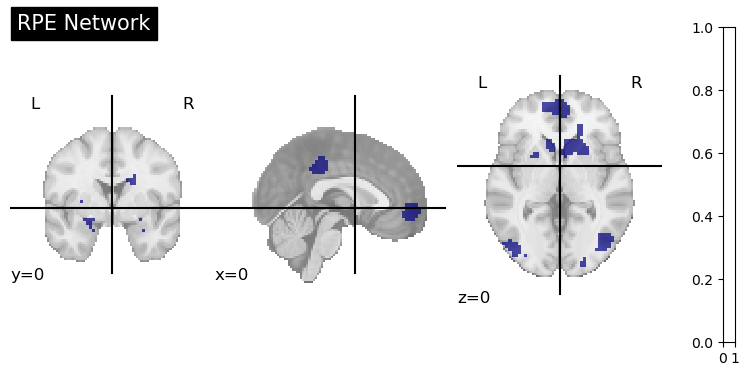

In [9]:
rpe_network = image.math_img('clusters != 0.0', clusters=clusters)

plotting.plot_roi(rpe_network, title='RPE Network', colorbar=True, cut_coords=(0, 0, 0), display_mode='ortho', threshold=0.5)

rpe_network.to_filename(base_dir / 'ROI' / 'RPE_network.nii.gz')

# Surprise

In [10]:
base_dir = root_folder / 'nipype' / 'model2' 
# cluster_mapping = {
#     0: "Caudate, Putamen R",
#     2: "Caudate, Putamen L",
#     7: "Angular Gyrus L",
#     4: "Visual cortex (Mid, Lat Occipital) L",
#     3: "vmPFC",
#     8: "Visual Cortex (Lingual, Fusiform) L",
#     5: "Cerebellum R"
# }

cluster_fn = root_folder / 'nipype' / 'model2' / '2ndLevel' / 'cluster_SnPM_SecondLevel_con5' / 'SnPM_filtered_t3_1_pos.nii'

df, clusters = get_clusters_table(cluster_fn, stat_threshold=3.1, return_label_maps=True)

df = df[df['Cluster Size (mm3)'] != '']
min_cluster_size = 75
df['Cluster size (voxels)'] = np.round(df['Cluster Size (mm3)'].astype(float) / (15.5)).astype(int)
df = df[df['Cluster size (voxels)'] > min_cluster_size]

df[['X', 'Y', 'Z']] = df[['X', 'Y', 'Z']].astype(int)

df.rename(columns={'Cluster ID': 'Cluster Index', 'X':'Max X', 'Y':'Max Y', 'Z':'Max Z',
                   'Peak Stat':'T', 'Cluster size (voxels)': 'Voxels'}, inplace=True)

df = df[['Cluster Index', 'Voxels', 'T', 'Max X', 'Max Y', 'Max Z']]

df['T'] = df['T'].round(2)
df['P_FWE_corr'] = 0.0002 
df.to_csv(base_dir / 'ROI' / 'snpm_stats_con5_3_1_pos.csv')

clusters = clusters[0]

/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/image/image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


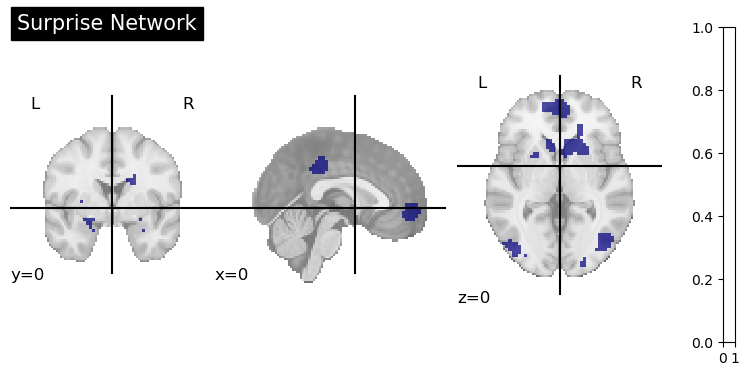

In [12]:
surprise_network = image.math_img('clusters != 0.0', clusters=clusters)

plotting.plot_roi(rpe_network, title='Surprise Network', colorbar=True, cut_coords=(0, 0, 0), display_mode='ortho', threshold=0.5)

surprise_network.to_filename(base_dir / 'ROI' / 'surprise_network.nii.gz')